# Grover's Algorithm (Basic example)

This notebook demonstrates a minimal implementation of Grover's Algorithm
for a small search space using Qiskit.

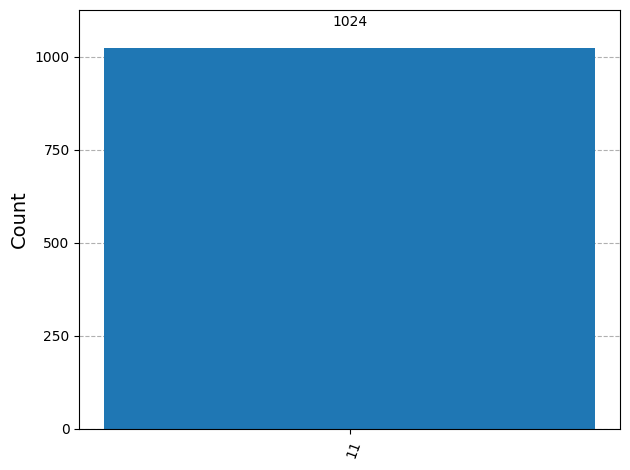

In [6]:
from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram
import numpy as np
import matplotlib.pyplot as plt

# Create a 2-qubit Grover circuit (search space is 4)
qc = QuantumCircuit(2, 2)

# Step 1: Initialize in superposition
qc.h([0, 1])

# Step 2: Oracle for the state |11>
qc.cz(0, 1)

'''
#if we want to mark |10> instead, we can use the following sequence
qc.x(1)
qc.cz(0,1)
qc.x(1)
#if we want to mark |01> instead, we can use the following sequence
qc.x(0)
qc.cz(0,1)
qc.x(0)
#if we want to mark |00> we can use the following sequence
qc.x([0,1])
qc.cz(0,1)
qc.x([0,1])
'''

# Step 3: Diffusion operator
qc.h([0, 1])
qc.x([0, 1])
qc.cz(0, 1)
qc.x([0, 1])
qc.h([0, 1])

#Measure
qc.measure([0,1],[0,1])

# To run 
backend = AerSimulator()
result = backend.run(qc, shots = 1024).result()
counts = result.get_counts()

#visualize the results
plot_histogram(counts)

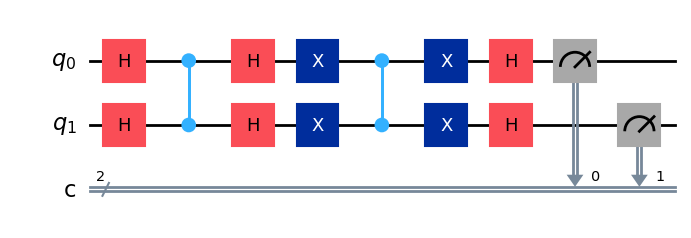

In [7]:
# See the circuit
qc.draw('mpl')

## Notes

You have N items, one is “marked”.
 - Classical search → O(N)
 - Quantum Grover → O(√N)
Grover amplifies the probability of the correct answer.

We’ll assume the state before as the uniform superposition:
```text
∣ψ⟩=21​(∣00⟩+∣01⟩+∣10⟩+∣11⟩)
'''
Or we apply hadamard gate to initialize it in superposition.

Now oracle: mark |11>
 so code is qc.cz(0,1)
 What CZ does:
    A controlled-Z gate applies a phase flip only when both qubits are 1:(for the particular state of oracle|11>)
            ∣11⟩→−∣11⟩
    All others:
            ∣00⟩,∣01⟩,∣10⟩→ Unchanged
After the Oracle: 
            ½​(∣00⟩+∣01⟩+∣10⟩−∣11⟩)

Now we use Diffusion Operator (Inversion About the Mean)
This is the Amplitude apmlifier
steps: 
    qc.h([0,1]) --- Changes basis from computational → Hadamard basis
                    Maps the uniform superposition back to |00>
    qc.x([0, 1]) --- ∣00⟩↔∣11⟩
                     Because we want to apply a phase flip to |00⟩, but CZ only flips |11⟩.
    qc.cz(0, 1) --- Phase flip about |00⟩
                    ∣00⟩→−∣00⟩, this is important step.
    qc.x([0, 1]) --- Undo X gates
                     return to original labeling
    qc.h([0, 1]) --- Undo Hadamards
                     return to computational basis.

Then measure and run


What the diffusion actually does (intuition)

After oracle:
 - One state has negative amplitude
 - Others are positive

Diffusion:
 - Computes the average amplitude
 - Reflects each amplitude around that average

So:
 - Marked state → amplitude increases
 - Others → amplitudes decrease
So this is the basic idea.

By modifying the oracle, the Grover circuit successfully amplifies
the target state ( |10⟩ /  |01⟩ ). The histogram peak shifts accordingly,
demonstrating that Grover’s algorithm amplifies whichever state is
marked by the oracle.

Full Grover flow:
        - Superposition
        - Oracle (marks target)
        - Diffusion
        - Measurement

## Observations and Results:

The histogram shows that the marked state |11⟩ appears with the
highest probability after measurement, while the other states occur
with significantly lower frequency.

This indicates successful amplitude amplification: the oracle marks
the target state by a phase flip, and the diffusion operator increases
its probability relative to the unmarked states.

Although the result is probabilistic, repeated measurements
consistently show the dominance of the marked state, confirming the
core idea behind Grover’s algorithm.

Grover doesn’t care which state you want,
it only amplifies what the oracle marks.


## Doubts and Concept Clearance

What the demo program i made mislead me into thinking:
it looks like:
        “We already KNOW the answer is |11|, so what’s the point?”
    But it’s an artifact of toy examples to easily understand the algororithm
     These examples are not realistic search problems — they are didactic.

The key thing is:
--------In a real Grover problem, We NEVER hard-code “mark |11⟩”.----------
    Instead, we hard-code a RULE.
    The oracle does not say:
                “Flip phase of |11⟩”
    instead it says:
                “Flip phase of any |x⟩ that satisfies this condition”

For example:
    “Flip phase of any |x⟩ that satisfies this condition”
    f(x)=1, if x is a solution
    We know how to compute f(x), but we don't know which x makes it 1.

Important Table:

'''text
| Toy Demo             | Real Grover                  |                             
| ---------------------| -----------------------------|  
| Oracle = “mark |11⟩” | Oracle = “check constraint”  |
| Answer is known      | Answer is unknown            |                             
| CZ gate              | Big reversible circuit       |              
| Teaching tool        | Computational model          |                             

'''
So:
 - Oracle defines which subspace.
 - Diffusion amplifies whatever was marked.

--------Grover is not a database search algorithm:-------------------
        It is a verifier-based search algorithm.

If we had to “know the answer” to build the oracle, Grover would be useless — and it isn’t.
What we must remember:
 - how to recognize a solution.
 - NOT which input is the solution.

WHEN WE LEARNT GROVER'S ALGORITHM, WE HARD-CODED THE SOLUTION FOR EASY UNDERSTANDING,
BUT REAL GROVER ORACLES ENCODES RULES, NOT ANSWERS. 
 

## Shots and Statistics for understanding with different parameters:

So now, we are gonna try with different shots:
        - shots = 128
        - shots = 256
        - shots = 2048 
Now we try it on circuit same as before

In [7]:
from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram

backend = AerSimulator()

def grover_circuit():
    qc = QuantumCircuit(2, 2)

    # Superposition
    qc.h([0, 1])

    # Oracle for |11>
    qc.cz(0, 1)

    # Diffusion
    qc.h([0, 1])
    qc.x([0, 1])
    qc.cz(0, 1)
    qc.x([0, 1])
    qc.h([0, 1])

    qc.measure([0, 1], [0, 1])
    return qc


Shots: 128, Counts: {'11': 128}


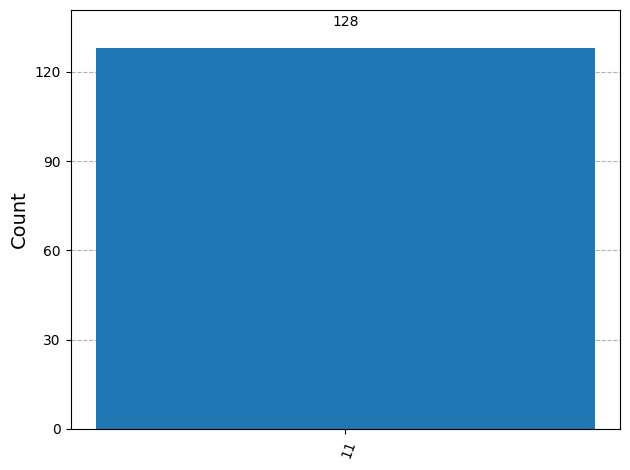

Shots: 256, Counts: {'11': 256}


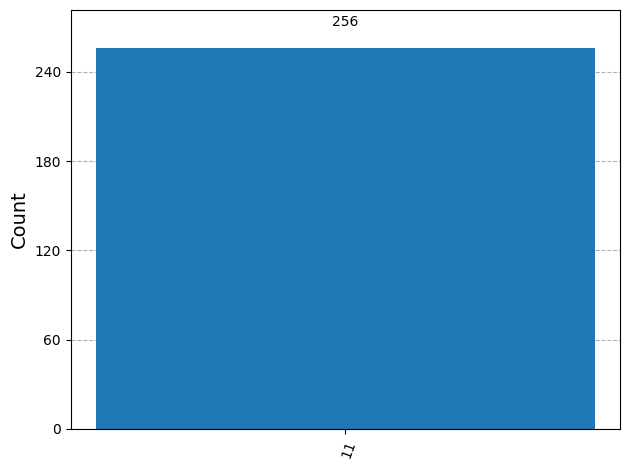

Shots: 2048, Counts: {'11': 2048}


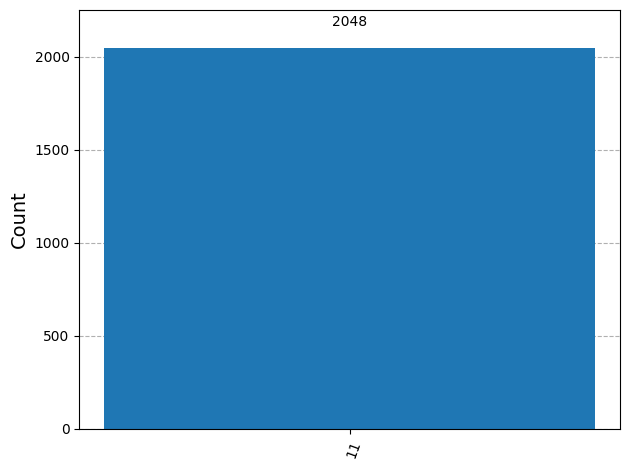

In [8]:
#Now running with different shots
shots_list = [128, 256, 2048]

for shots in shots_list:
    qc = grover_circuit()
    result = backend.run(qc, shots=shots).result()
    counts = result.get_counts()
    print(f"Shots: {shots}, Counts: {counts}")
    display(plot_histogram(counts))

## Observations:

Why we see 11 only everytime above:
Right now, our circuit:
    - has perfect superposition.
    - Uses one full Grover iteration.
    - Runs on an ideal Simulator(no noise).

For 2-qubit search spaces(4 states):
    - 1 Grover iteration is already optimal.
    - The target state |11> gets amplified very strongly
    - so even at 128 shots, othyer states may appear 0 times.
    So this is expected. 

## To study differences:

We must deliberately change the setup.
Option 1: Remove the Diffusion operator


Shots = 128


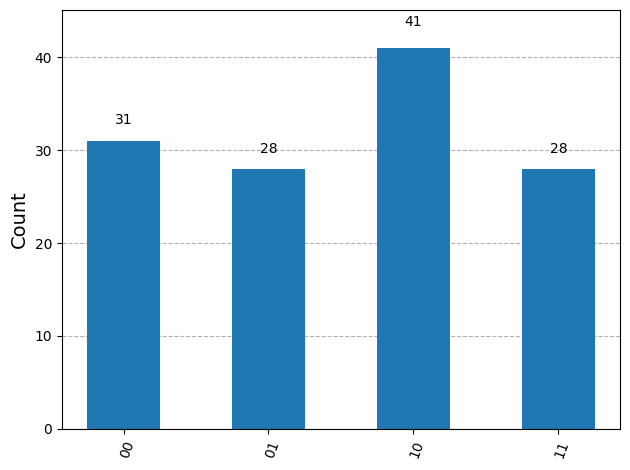


Shots = 256


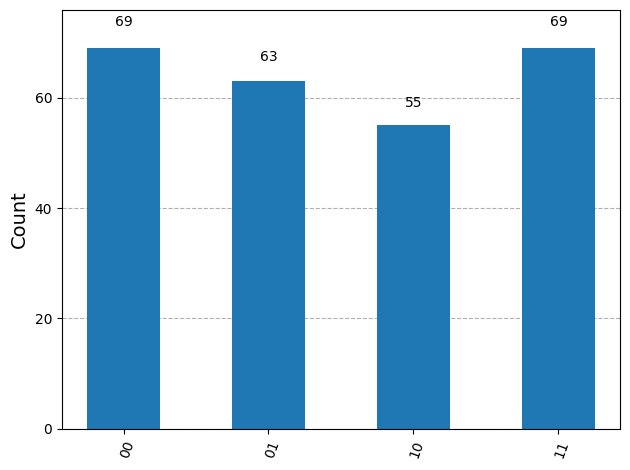


Shots = 2048


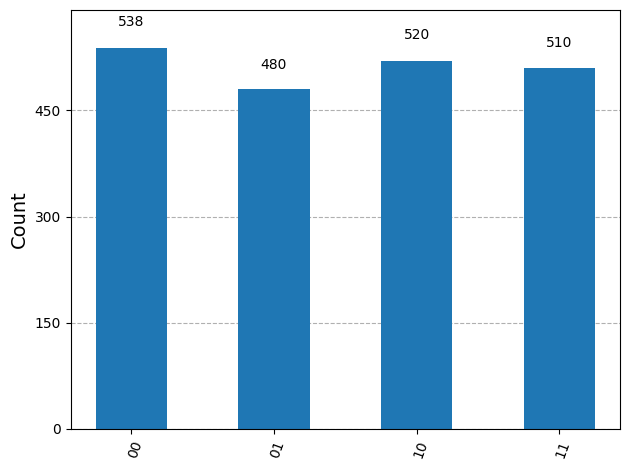

In [9]:
from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram
from IPython.display import display

backend = AerSimulator()

# Define a weakened Grover circuit (oracle only)
def grover_oracle_only():
    qc = QuantumCircuit(2, 2)
    qc.h([0, 1])        # Superposition
    qc.cz(0, 1)         # Oracle (marks |11>)
    qc.measure([0, 1], [0, 1])
    return qc

shots_list = [128, 256, 2048]

for shots in shots_list:
    qc = grover_oracle_only()
    result = backend.run(qc, shots=shots).result()
    counts = result.get_counts()

    print(f"\nShots = {shots}")
    display(plot_histogram(counts))


## Observations

- 128 shots = Noisy distribution.
- 256 shots = smoother.
- 2048 shots = stable.

Stability does not mean: one bar dominates.
that would happen only if we applied full grover(oracle + diffusion)
Stability means: As shots increases, probabilities stop fluctuatuing wildly and settle around expected values.

"Stability means convergence to expected probabilities,
 not dominance of a particular state."